<a href="https://colab.research.google.com/github/katiacardoso/Chapeu_Seletor_HarryPotter/blob/main/Dataframe_sem_feiti%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install lazypredict

## Importação de bibliotecas

In [ ]:
!pip install dask

In [ ]:
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

#para geração da árvore
from sklearn.tree import export_graphviz
import graphviz

#from sklearn.model_selection import GridSearchCV
from itertools import product
import pandas as pd
import numpy as np

#from lazypredict.Supervised import LazyClassifier    # !pip install lazypredict

#para geração da visualização da matriz confusão
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#SHOW DO LAZY PREDICT QUERENDO FAZER GRAÇA

!find /usr/local/lib/python3.10/dist-packages -name "Supervised.py"
!sed -i 's/sparse=False/sparse_output=False/' /usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py
from lazypredict.Supervised import LazyClassifier

/usr/local/lib/python3.10/dist-packages/lazypredict/Supervised.py


## Verificação de versões utizadas

In [ ]:
import sklearn
import lazypredict
import seaborn
import matplotlib
import pandas as pd
import numpy as np


# Versão do scikit-learn
print("Versão do scikit-learn:", sklearn.__version__)

# Versão do lazypredict
print("Versão do lazypredict:", lazypredict.__version__)

# Versão do seaborn
print("Versão do seaborn:", seaborn.__version__)

# Versão do matplotlib
print("Versão do matplotlib:", matplotlib.__version__)

# Versão do pandas
print("Versão do pandas:", pd.__version__)

# Versão do numpy
print("Versão do numpy:", np.__version__)

# Versão do numpy
print("Versão do graphviz:", graphviz.__version__)

Versão do scikit-learn: 1.5.2
Versão do lazypredict: 0.2.12
Versão do seaborn: 0.13.1
Versão do matplotlib: 3.7.1
Versão do pandas: 2.2.2
Versão do numpy: 1.26.4
Versão do graphviz: 0.20.3


In [ ]:
notas = ['altas', 'medias', 'baixas']
interesses = ['magia', 'esportes', 'estudos', 'herbologia']
personalidades = ['ambicioso', 'inteligente', 'corajoso','leal','criativo']
casas = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']
ascendencias = ['puro', 'mestiço', 'nascidos_trouxa']
cor_cabelo = ['escuro', 'loiro', 'ruivo']
cor_olhos = ['azul', 'verde', 'castanho', 'preto']


# Crie todas as combinações possíveis
combinacoes = list(product(notas, interesses, personalidades,ascendencias,cor_cabelo, cor_olhos))

print("Exemplo de combinação:", combinacoes[2],"\n")
print("Quantidade de combinações: ", len(combinacoes))

Exemplo de combinação: ('altas', 'magia', 'ambicioso', 'puro', 'escuro', 'castanho') 

Quantidade de combinações:  2160


In [ ]:
# Criação do DataFrame
df = pd.DataFrame(combinacoes, columns=['nota', 'interesse', 'personalidade', 'ascendencia', 'cor_cabelo', 'cor_olhos'])

# Adicione a coluna 'casa', atribuindo as casas de maneira rotativa
df['casa'] = [casas[i % len(casas)] for i in range(len(df))]

print(df.head())

    nota interesse personalidade ascendencia cor_cabelo cor_olhos        casa
0  altas     magia     ambicioso        puro     escuro      azul  Grifinória
1  altas     magia     ambicioso        puro     escuro     verde   Lufa-Lufa
2  altas     magia     ambicioso        puro     escuro  castanho    Corvinal
3  altas     magia     ambicioso        puro     escuro     preto   Sonserina
4  altas     magia     ambicioso        puro      loiro      azul  Grifinória


In [ ]:
from prettytable import PrettyTable

# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 1 do Dataframe"
print(table)
df.shape

+---------------------------------------------------------------------------------------+
|                              Visualização 1 do Dataframe                              |
+-------+-----------+---------------+-------------+------------+-----------+------------+
|  Nota | Interesse | Personalidade | Ascendencia | Cor Cabelo | Cor Olhos |    Casa    |
+-------+-----------+---------------+-------------+------------+-----------+------------+
| altas |   magia   |   ambicioso   |     puro    |   escuro   |    azul   | Grifinória |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |   verde   | Lufa-Lufa  |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |  castanho |  Corvinal  |
| altas |   magia   |   ambicioso   |     puro    |   escuro   |   preto   | Sonserina  |
| altas |   magia   |   ambicioso   |     puro    |   loiro    |    azul   | Grifinória |
+-------+-----------+---------------+-------------+------------+-----------+------------+


(2160, 7)

In [ ]:
# Embaralha o DataFrame para que as combinações sejam distribuídas aleatoriamente entre as casas e reconfigura o índice para começar do zero
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:

# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 2 do Dataframe"
print(table)
df.shape

+--------------------------------------------------------------------------------------------+
|                                Visualização 2 do Dataframe                                 |
+--------+------------+---------------+-----------------+------------+-----------+-----------+
|  Nota  | Interesse  | Personalidade |   Ascendencia   | Cor Cabelo | Cor Olhos |    Casa   |
+--------+------------+---------------+-----------------+------------+-----------+-----------+
| baixas |  estudos   |    criativo   |     mestiço     |   loiro    |   preto   | Sonserina |
| baixas | herbologia |  inteligente  |       puro      |   ruivo    |   verde   | Lufa-Lufa |
| medias |  esportes  |   ambicioso   |     mestiço     |   loiro    |  castanho |  Corvinal |
| altas  | herbologia |    criativo   | nascidos_trouxa |   loiro    |   verde   | Lufa-Lufa |
| baixas |  esportes  |   ambicioso   |     mestiço     |   loiro    |  castanho |  Corvinal |
+--------+------------+---------------+-----------

(2160, 7)

In [ ]:
'''
# Defina regras para evitar certas combinações
regras = [
    (df['tipo_sanguineo'] == 'x') & (df['lealdade'] == 'Voldemort') & (df['casa'] == 'Lufa-Lufa')
]

# Aplicar as regras
for regra in regras:
    df = df[~regra]
'''

df.to_csv('dt.csv', index=False)

# Criar uma cópia do DataFrame
df_copia = df.copy()

# Salvar a cópia com um nome diferente
df_copia.to_csv('gb.csv', index=False)

#print(df, '\n')
#df.head()


# Crie um LabelEncoder
le = LabelEncoder().fit(['altas', 'medias', 'baixas',
                         'magia', 'esportes', 'estudos', 'herbologia',
                         'ambicioso', 'inteligente', 'corajoso','leal','criativo',
                         'Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina',
                         'puro', 'mestiço', 'nascidos_trouxa',
                         'escuro', 'castanho', 'loiro', 'ruivo',
                         'azul', 'verde', 'castanho','preto'])

# Transforme os dados usando o LabelEncoder
df['nota'] = le.transform(df['nota'])
df['interesse'] = le.transform(df['interesse'])
df['personalidade'] = le.transform(df['personalidade'])
df['casa'] = le.transform(df['casa'])
df['ascendencia'] = le.transform(df['ascendencia'])
df['cor_cabelo'] = le.transform(df['cor_cabelo'])
df['cor_olhos'] = le.transform(df['cor_olhos'])

# Imprima os rótulos convertidos
print(df.head())
#print(df['casa'])

   nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos  casa
0     7         13             10           20          17         22     3
1     7         14             15           23          24         25     2
2    19         12              5           20          17          8     0
3     4         14             10           21          17         25     2
4     7         12              5           20          17          8     0


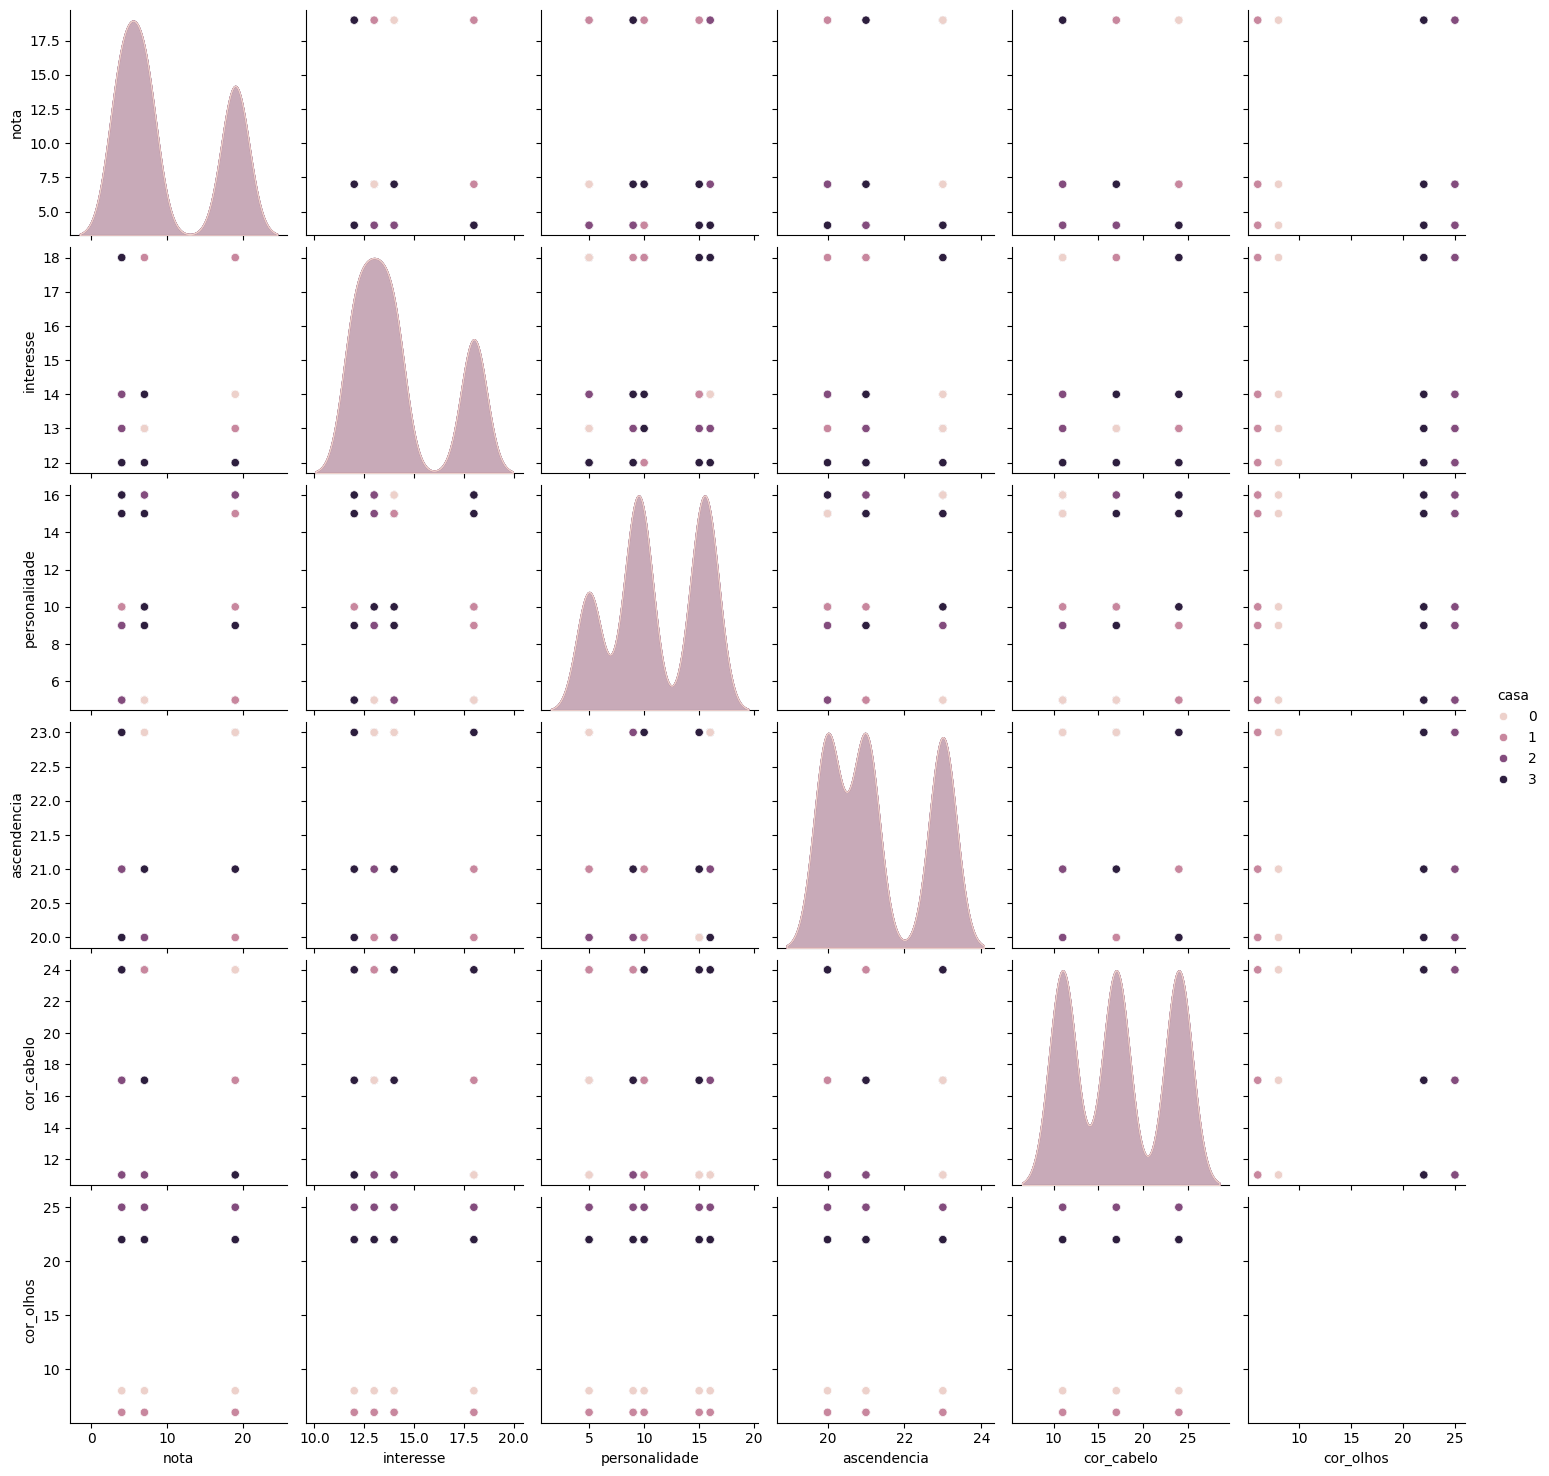

In [ ]:
import seaborn as sns
import pandas as pd

# Criando um gráfico de pares, colorindo por casa e usando densidade nuclear na diagonal
sns.pairplot(df, hue='casa', diag_kind='kde')
plt.show()

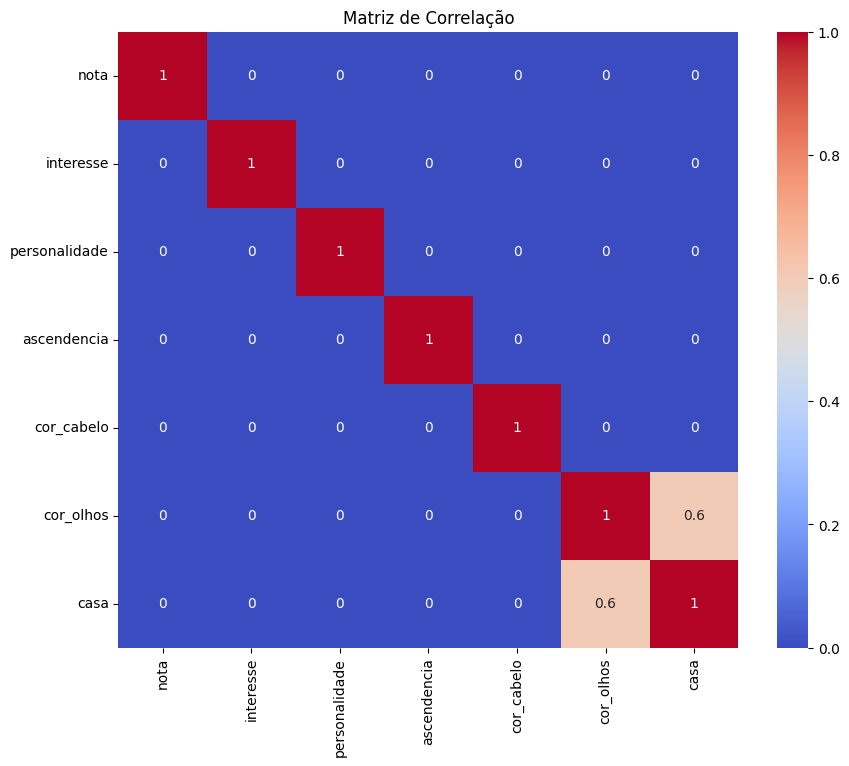

In [ ]:
# Calculando a matriz de correlação
corr_matrix = df.corr(method='spearman')

# Visualizando a matriz de correlação como um heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação apresentada indica que:

Pouca correlação entre as variáveis: A maioria das células da matriz apresenta valores próximos a zero, o que sugere que não há uma relação linear forte entre as variáveis.
Correlação positiva entre "cor_olhos" e "casa": Há uma correlação positiva moderada (0.6) entre a cor dos olhos e a casa. Isso indica que a cor dos olhos pode ter alguma influência na classificação da casa, mas não de forma determinante.

In [ ]:
# Criando uma tabela com as 5 primeiras linhas
table = PrettyTable(['Nota', 'Interesse', 'Personalidade', 'Ascendencia', 'Cor Cabelo', 'Cor Olhos', 'Casa'])
table.add_rows(df.head().values.tolist())
table.title = "Visualização 3 do Dataframe"
print(table)
df.shape

+--------------------------------------------------------------------------------+
|                          Visualização 3 do Dataframe                           |
+------+-----------+---------------+-------------+------------+-----------+------+
| Nota | Interesse | Personalidade | Ascendencia | Cor Cabelo | Cor Olhos | Casa |
+------+-----------+---------------+-------------+------------+-----------+------+
|  7   |     13    |       10      |      20     |     17     |     22    |  3   |
|  7   |     14    |       15      |      23     |     24     |     25    |  2   |
|  19  |     12    |       5       |      20     |     17     |     8     |  0   |
|  4   |     14    |       10      |      21     |     17     |     25    |  2   |
|  7   |     12    |       5       |      20     |     17     |     8     |  0   |
+------+-----------+---------------+-------------+------------+-----------+------+


(2160, 7)

In [ ]:
# Obter os rótulos codificados
casas_codificados = le.transform(casas)

# Criar um DataFrame para mostrar a correspondência
mapping_df = pd.DataFrame({'Casa Original': casas, 'Código': casas_codificados})

#print(mapping_df)
# Criando a tabela PrettyTable
table = PrettyTable()
table.add_column("Casa Original", mapping_df['Casa Original'].tolist())
table.add_column("Código", mapping_df['Código'].tolist())
# Imprimindo a tabela
print(table)

+---------------+--------+
| Casa Original | Código |
+---------------+--------+
|   Grifinória  |   1    |
|   Lufa-Lufa   |   2    |
|    Corvinal   |   0    |
|   Sonserina   |   3    |
+---------------+--------+


In [ ]:
X = df[['nota', 'interesse', 'personalidade', 'ascendencia',  'cor_cabelo', 'cor_olhos']]
y = df['casa']


# Dividir os dados em treinamento e teste (70% treino, 30% teste)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df['casa'])

# Dividir o conjunto de teste em teste e validação (20% teste, 10% validação)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp)

In [ ]:
# Criar DataFrames para cada conjunto
train_df = pd.DataFrame({'Conjunto': 'Treino', 'Classe': y_train})
test_df = pd.DataFrame({'Conjunto': 'Teste', 'Classe': y_test})
val_df = pd.DataFrame({'Conjunto': 'Validação', 'Classe': y_val})

# Concatenar os DataFrames para facilitar a criação da tabela
combined_df = pd.concat([train_df, test_df, val_df], ignore_index=True)

# Contar a frequência de cada classe em cada conjunto
counts = combined_df.groupby(['Conjunto', 'Classe']).size().reset_index(name='Contagem')

# Criar a tabela PrettyTable
table = PrettyTable()
table.field_names = ["Conjunto", "Classe", "Contagem"]
table.add_rows(counts.values.tolist())


# Imprimir a tabela
print(table)
df.shape

+-----------+--------+----------+
|  Conjunto | Classe | Contagem |
+-----------+--------+----------+
|   Teste   |   0    |   113    |
|   Teste   |   1    |   114    |
|   Teste   |   2    |   113    |
|   Teste   |   3    |   113    |
|   Treino  |   0    |   378    |
|   Treino  |   1    |   378    |
|   Treino  |   2    |   378    |
|   Treino  |   3    |   378    |
| Validação |   0    |    49    |
| Validação |   1    |    48    |
| Validação |   2    |    49    |
| Validação |   3    |    49    |
+-----------+--------+----------+


(2160, 7)

In [ ]:
print("Tamanho do conjunto de treinamento:", len(X_train))
print("Quantidade de variáveis no conjunto de treinamento:", X_train.shape[1])

print("Tamanho do conjunto de teste:", len(X_test))
print("Quantidade de variáveis no conjunto de teste:", X_test.shape[1])

print("Tamanho do conjunto de validação:", len(X_val))
print("Quantidade de variáveis no conjunto de validação:", X_val.shape[1])


Tamanho do conjunto de treinamento: 1512
Quantidade de variáveis no conjunto de treinamento: 6
Tamanho do conjunto de teste: 453
Quantidade de variáveis no conjunto de teste: 6
Tamanho do conjunto de validação: 195
Quantidade de variáveis no conjunto de validação: 6


In [ ]:
print(X_train.value_counts())
print(X_test.value_counts())
print(X_val.value_counts())

nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos
4     12         5              20           11          6            1
19    12         5              20           17          25           1
                                21           17          25           1
                                                         8            1
                                                         6            1
                                                                     ..
7     12         5              20           11          8            1
                                                         6            1
4     18         16             23           24          22           1
                                                         8            1
19    18         16             23           24          8            1
Name: count, Length: 1512, dtype: int64
nota  interesse  personalidade  ascendencia  cor_cabelo  cor_olhos
4     12         5              20

In [ ]:
# Contando o número de dados de cada classe (altere para qual desejar)
contagem_de_classes = df["casa"].value_counts()

# Imprimindo o resultado
print(contagem_de_classes)

casa
3    540
2    540
0    540
1    540
Name: count, dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   nota           2160 non-null   int64
 1   interesse      2160 non-null   int64
 2   personalidade  2160 non-null   int64
 3   ascendencia    2160 non-null   int64
 4   cor_cabelo     2160 non-null   int64
 5   cor_olhos      2160 non-null   int64
 6   casa           2160 non-null   int64
dtypes: int64(7)
memory usage: 118.2 KB
None


## Lazy Predict

In [ ]:
# Inicializar o LazyClassifier
clf = LazyClassifier()
models,predictions = clf.fit(X_train,X_test, y_train,y_test)
model_dictionary = clf.provide_models(X_train, X_train,y_train,y_test)
models
#modelos, pontuacoes = clf.fit(X_train,X_test, y_train,y_test)

# Exibir os modelos e suas pontuações
#print(modelos)
#modelos
#print(pontuacoes)

 87%|████████▋ | 27/31 [00:02<00:00, 14.68it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28
[LightGBM] [Info] Number of data points in the train set: 1512, number of used features: 6
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

100%|██████████| 31/31 [00:02<00:00, 12.66it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LinearSVC,1.00,1.00,None,1.00,0.03
GaussianNB,1.00,1.00,None,1.00,0.02
XGBClassifier,1.00,1.00,None,1.00,0.09
RandomForestClassifier,1.00,1.00,None,1.00,0.23
NuSVC,1.00,1.00,None,1.00,0.18
LogisticRegression,1.00,1.00,None,1.00,0.04
BaggingClassifier,1.00,1.00,None,1.00,0.09
LinearDiscriminantAnalysis,1.00,1.00,None,1.00,0.02
LGBMClassifier,1.00,1.00,None,1.00,0.26


In [ ]:
'''# Dividir em conjuntos de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializar o LazyClassifier
clf = LazyClassifier()
modelos, pontuacoes = clf.fit(X_treino, X_teste, y_treino, y_teste)

# Exibir os modelos e suas pontuações
#print(modelos)
modelos
#print(pontuacoes)'''

'# Dividir em conjuntos de treino e teste\nX_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)\n\n# Inicializar o LazyClassifier\nclf = LazyClassifier()\nmodelos, pontuacoes = clf.fit(X_treino, X_teste, y_treino, y_teste)\n\n# Exibir os modelos e suas pontuações\n#print(modelos)\nmodelos\n#print(pontuacoes)'

In [ ]:
# Criação do modelo de  ExtraTree
model_extra_tree = ExtraTreeClassifier(random_state=42, class_weight='balanced')
model_extra_tree.fit(X_train, y_train)

# Faça previsões no conjunto de teste
y_pred = model_extra_tree.predict(X_test)

y_pred
print("y_pred: ", y_pred)
'''# Calcule a acurácia
acuracia_dt = accuracy_score(y_test, y_pred)
print("Acurácia:", acuracia_dt)
#ou
acuracia_dt = model_extra_tree.score(X_test, y_test)
print(acuracia_dt)'''


unique_classes = np.unique(np.concatenate((y_test, y_pred)))
relatorio = classification_report(y_test, y_pred, target_names=le.inverse_transform(unique_classes))
print(relatorio)

y_pred:  [3 0 1 3 1 0 1 3 0 2 3 1 1 1 1 3 0 1 1 3 2 3 3 2 2 3 0 2 0 1 0 1 2 3 1 0 2
 3 0 3 3 1 2 1 0 1 1 2 2 2 2 3 2 1 0 2 0 0 1 2 1 3 1 2 3 1 0 1 1 1 1 2 0 2
 1 2 3 1 2 3 0 1 1 0 2 2 2 1 1 0 1 2 0 3 3 1 1 1 3 3 1 3 1 2 3 0 0 1 1 0 1
 2 3 3 3 0 1 3 3 0 0 0 1 0 3 2 2 3 2 2 3 3 0 3 1 3 3 1 1 3 3 1 2 2 2 3 0 3
 2 3 1 2 0 0 1 1 3 1 2 1 0 3 2 0 3 0 0 1 0 2 1 0 0 2 3 0 1 0 2 2 1 2 1 2 3
 3 3 3 0 2 0 2 0 0 0 3 2 0 0 1 3 2 1 3 2 0 3 0 0 2 2 3 1 0 1 2 1 3 2 0 1 1
 2 1 3 3 3 2 2 1 2 2 1 3 0 2 2 0 2 2 2 0 3 0 0 0 3 1 1 3 2 0 0 2 0 1 2 2 3
 3 3 2 2 0 1 0 3 2 3 0 3 0 1 2 1 2 3 2 1 1 3 0 3 0 2 1 2 3 2 2 0 2 1 1 2 3
 0 2 0 2 0 1 2 3 3 2 1 3 3 0 0 0 3 1 3 2 0 2 3 1 2 3 2 3 3 1 1 2 1 0 0 0 0
 2 3 1 3 0 3 1 0 3 0 1 1 0 0 3 1 1 0 2 0 1 0 3 2 2 3 1 0 2 3 2 1 2 3 1 0 2
 1 0 3 2 2 2 3 0 3 1 2 3 0 2 0 0 2 3 1 1 1 1 2 0 3 1 0 1 2 1 1 0 3 3 1 0 3
 1 3 3 2 1 2 0 1 2 3 0 3 0 3 1 0 2 2 0 3 0 1 1 1 2 2 1 1 3 0 1 2 2 2 1 1 0
 0 1 1 3 3 2 3 3 1]
              precision    recall  f1-score   support

    Corvinal    

Precisão (precision): Indica a proporção de exemplos classificados como positivos que realmente são positivos. Por exemplo, a precisão da Corvinal de 0.86 significa que, de todos os alunos classificados como Corvinal, 86% realmente pertencem à Corvinal.

Recall (recall): Indica a proporção de exemplos positivos que foram corretamente classificados. Por exemplo, o recall da Grifinória de 0.89 significa que o modelo conseguiu identificar 89% dos alunos da Grifinória.

F1-score: É a média harmônica da precisão e do recall, oferecendo um bom equilíbrio entre as duas métricas. Um F1-score alto indica um bom desempenho tanto em termos de precisão quanto de recall.

Support: Indica o número de exemplos de cada classe no conjunto de teste.

Análise Geral:

Bom desempenho: O modelo apresenta um desempenho geral bastante bom, com valores de precisão, recall e F1-score próximos de 1 para todas as classes.
Equilíbrio: O modelo parece equilibrar bem a precisão e o recall para todas as classes, o que indica que ele está classificando os alunos de forma precisa e completa.
Classes balanceadas: O número de exemplos em cada classe é bastante similar (113 ou 114), o que facilita a interpretação das métricas.
Análise por Classe:

Corvinal: O modelo tem um desempenho ligeiramente abaixo da média em relação às outras casas.
Grifinória: O modelo apresenta um desempenho muito bom, com valores de precisão, recall e F1-score próximos de 0.9.
Lufa-Lufa: O modelo tem o melhor desempenho para esta classe, com valores muito próximos de 1.
Sonserina: O modelo também apresenta um bom desempenho para esta classe.
Considerações Adicionais:

Matriz de confusão: Uma matriz de confusão pode fornecer informações mais detalhadas sobre os erros de classificação.
Curva ROC: A curva ROC pode ser útil para avaliar o desempenho do modelo em diferentes limiares de classificação.
Desbalanceamento de classes: Se as classes estivessem desbalanceadas, seria necessário analisar as métricas com mais cuidado, pois a acurácia geral pode ser enganosa.


In [ ]:
df['nota'] = le.inverse_transform(df['nota'])
df['interesse'] = le.inverse_transform(df['interesse'])
df['personalidade'] = le.inverse_transform(df['personalidade'])
df['casa'] = le.inverse_transform(df['casa'])
df['ascendencia'] = le.inverse_transform(df['ascendencia'])
df['cor_cabelo'] = le.inverse_transform(df['cor_cabelo'])
df['cor_olhos'] = le.inverse_transform(df['cor_olhos'])


print("Classes Previstas:", y_pred)
print("Classes Verdadeiras:\n", y_test)


# Agora você pode visualizar os dados de treinamento e teste com os rótulos originais
print("Dados de treinamento:")
print(X_train)
print(y_train)

print("\nDados de teste:")
print(X_test)
print(y_test)

Classes Previstas: [3 0 1 3 1 0 1 3 0 2 3 1 1 1 1 3 0 1 1 3 2 3 3 2 2 3 0 2 0 1 0 1 2 3 1 0 2
 3 0 3 3 1 2 1 0 1 1 2 2 2 2 3 2 1 0 2 0 0 1 2 1 3 1 2 3 1 0 1 1 1 1 2 0 2
 1 2 3 1 2 3 0 1 1 0 2 2 2 1 1 0 1 2 0 3 3 1 1 1 3 3 1 3 1 2 3 0 0 1 1 0 1
 2 3 3 3 0 1 3 3 0 0 0 1 0 3 2 2 3 2 2 3 3 0 3 1 3 3 1 1 3 3 1 2 2 2 3 0 3
 2 3 1 2 0 0 1 1 3 1 2 1 0 3 2 0 3 0 0 1 0 2 1 0 0 2 3 0 1 0 2 2 1 2 1 2 3
 3 3 3 0 2 0 2 0 0 0 3 2 0 0 1 3 2 1 3 2 0 3 0 0 2 2 3 1 0 1 2 1 3 2 0 1 1
 2 1 3 3 3 2 2 1 2 2 1 3 0 2 2 0 2 2 2 0 3 0 0 0 3 1 1 3 2 0 0 2 0 1 2 2 3
 3 3 2 2 0 1 0 3 2 3 0 3 0 1 2 1 2 3 2 1 1 3 0 3 0 2 1 2 3 2 2 0 2 1 1 2 3
 0 2 0 2 0 1 2 3 3 2 1 3 3 0 0 0 3 1 3 2 0 2 3 1 2 3 2 3 3 1 1 2 1 0 0 0 0
 2 3 1 3 0 3 1 0 3 0 1 1 0 0 3 1 1 0 2 0 1 0 3 2 2 3 1 0 2 3 2 1 2 3 1 0 2
 1 0 3 2 2 2 3 0 3 1 2 3 0 2 0 0 2 3 1 1 1 1 2 0 3 1 0 1 2 1 1 0 3 3 1 0 3
 1 3 3 2 1 2 0 1 2 3 0 3 0 3 1 0 2 2 0 3 0 1 1 1 2 2 1 1 3 0 1 2 2 2 1 1 0
 0 1 1 3 3 2 3 3 1]
Classes Verdadeiras:
 786     3
601     0
2038    1
1569    3

In [ ]:
from sklearn.metrics import log_loss

log_loss_value = log_loss(y_test, model_extra_tree.predict_proba(X_test))
print("Log-Loss:", log_loss_value)

Log-Loss: 1.8300309667763677


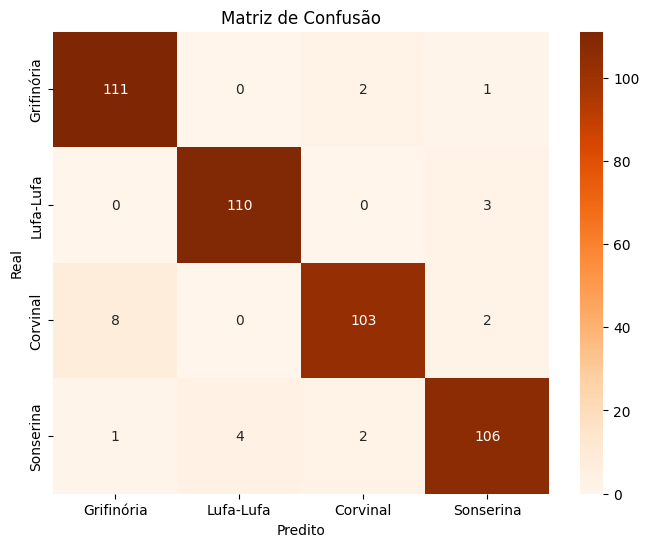

              precision    recall  f1-score   support

  Grifinória       0.96      0.91      0.94       113
   Lufa-Lufa       0.93      0.97      0.95       114
    Corvinal       0.96      0.97      0.97       113
   Sonserina       0.95      0.94      0.94       113

    accuracy                           0.95       453
   macro avg       0.95      0.95      0.95       453
weighted avg       0.95      0.95      0.95       453



In [ ]:
# Mapeando os valores preditos de volta para os rótulos das classes
class_labels = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']

# Inverter a transformação do Label Encoder
y_pred_originais = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)

# Converter ambos y_test e y_pred_originais para o mesmo tipo de dados (neste caso, string)
y_test_str = y_test.astype(str)
y_pred_str = y_pred_originais.astype(str)

# Verificando se todas as classes em class_labels estão presentes em y_test_str
for label in class_labels:
    if label not in y_test_str:
        print(f"A classe {label} não está presente nos rótulos reais.")
        # Trate essa situação, talvez removendo a classe ausente de class_labels ou tomando outra ação apropriada.


# Criando a matriz de confusão
conf_matrix = confusion_matrix(y_test_str, y_pred_str, labels=class_labels)

# Plotando a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# Imprimindo relatórios de classificação
print(classification_report(y_test_str, y_pred_str, target_names=class_labels))

Diagonais: Os valores na diagonal principal (de cima para baixo, da esquerda para a direita) representam os casos em que o modelo classificou corretamente um exemplo. Por exemplo, o valor 101 na diagonal indica que 101 alunos que realmente pertenciam à Grifinória foram corretamente classificados como Grifinória.

Fora da diagonal: Os valores fora da diagonal representam os casos em que o modelo classificou erroneamente um exemplo. Por exemplo, o valor 12 na primeira linha e terceira coluna indica que 12 alunos que realmente pertenciam à Grifinória foram classificados como Corvinal.

Analisando os resultados:

Bom desempenho: A matriz mostra que o modelo tem um desempenho geral muito bom, com a maioria dos exemplos sendo classificados corretamente em suas respectivas casas.
Erros de classificação: A maioria dos erros de classificação ocorre entre casas que podem ter características semelhantes ou alunos com características ambíguas. Por exemplo, alguns alunos da Grifinória podem ter sido classificados como Corvinal e vice-versa.
Desempenho por classe: A Lufa-Lufa parece ser a classe mais fácil de classificar, com poucos erros de classificação. A Grifinória e a Corvinal apresentam um número similar de erros de classificação entre si. A Sonserina também apresenta um bom desempenho, com poucos erros.
Conclusão:

A matriz de confusão confirma a alta acurácia do modelo de classificação, como já indicado pelas métricas de precisão, recall e F1-score. No entanto, a matriz nos permite identificar os tipos de erros que o modelo está cometendo e quais classes podem ser mais desafiadoras de classificar.

In [ ]:
from sklearn.tree import plot_tree


# Obter o número real de features
n_features = X.shape[1]


# 1. Visualização com matplotlib (limitando a profundidade)
plt.figure(figsize=(30,20))  # Aumentando o tamanho da figura
plot_tree(model_extra_tree,
          max_depth=5,  # Limitando a profundidade para melhor visualização
          feature_names=[f'Feature {i}' for i in range(n_features)],
          class_names=['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina'],
          filled=True,
          rounded=True,
          fontsize=10)  # Aumentando o tamanho da fonte
plt.title("Visualização do ExtraTreeClassifier (Profundidade Limitada)", fontsize=20)
plt.savefig('extratree_depth_limited.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Visualização interativa com graphviz
dot_data = export_graphviz(model_extra_tree,
                           max_depth=5,  # Limitando a profundidade
                           feature_names=[f'Feature {i}' for i in range(n_features)],
                           class_names=['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina'],
                           filled=True,
                           rounded=True)
graph = graphviz.Source(dot_data)
graph.render("extratree_interactive", format="pdf", view=True)

# Imprimir informações sobre a árvore
print(f"Profundidade da árvore: {model_extra_tree.get_depth()}")
print(f"Número de nós folha: {model_extra_tree.get_n_leaves()}")


Profundidade da árvore: 13
Número de nós folha: 213


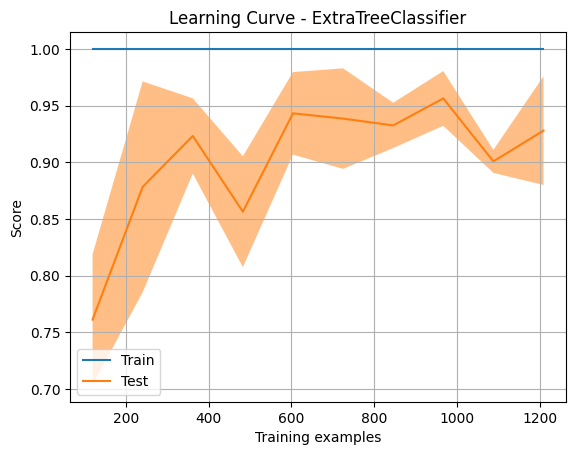

In [ ]:
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold
# 2. Definindo a validação cruzada (StratifiedKFold)
# Utilizamos StratifiedKFold para garantir que a divisão das classes seja balanceada em cada fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Gerando o gráfico de curva de aprendizado
# Aqui, definimos o 'train_sizes' como o intervalo entre 10% e 100% dos dados de treinamento.
LearningCurveDisplay.from_estimator(
    model_extra_tree, X_train, y_train, cv=cv, n_jobs=-1, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# 4. Configurando o gráfico
plt.title("Learning Curve - ExtraTreeClassifier")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.grid(True)
plt.show()

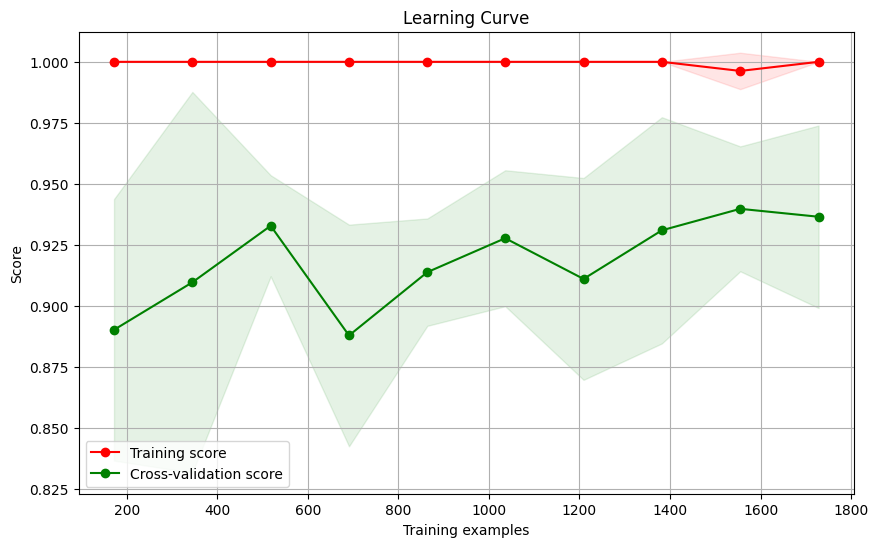

In [ ]:
# Função para plotar a curva de aprendizado
def plot_learning_curve(estimator, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curve")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plote a curva de aprendizado para o seu modelo
plot_learning_curve(model_extra_tree, X, y, cv=5)


In [ ]:
# Obter a importância das características
importancias_caracteristicas = model_extra_tree.feature_importances_

# Mostrar a importância das características
for i, importancia in enumerate(importancias_caracteristicas):
    print(f'Característica {X.columns[i]}: {importancia}')

# Verificar se há alguma característica com grande importância
importancia_maxima = max(importancias_caracteristicas)
print("\nA maior importância encontrada:", importancia_maxima)

# Calcular a média da importância das características
importancia_media = np.mean(importancias_caracteristicas)
print("\nA média da importância das características:", importancia_media)


Característica nota: 0.0025258316887972368
Característica interesse: 0.0061597411659096045
Característica personalidade: 0.004930811692709495
Característica ascendencia: 0.0013927957487538205
Característica cor_cabelo: 0.004442613654506639
Característica cor_olhos: 0.9805482060493232

A maior importância encontrada: 0.9805482060493232

A média da importância das características: 0.16666666666666666


In [ ]:
# Obtendo a importância das features
importances = model_extra_tree.feature_importances_

# Criando um DataFrame para visualizar os resultados
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

print(feature_importances)

         feature  importance
5      cor_olhos        0.98
1      interesse        0.01
2  personalidade        0.00
4     cor_cabelo        0.00
0           nota        0.00
3    ascendencia        0.00


In [ ]:
from sklearn.metrics import log_loss
# Fazer previsões nos dados de validação
predicoes_validacao =  model_extra_tree.predict(X_val)

# Avaliar o desempenho do modelo nos dados de validação
print("Acurácia:", accuracy_score(y_val, predicoes_validacao))
print("Precisão:", precision_score(y_val, predicoes_validacao, average='weighted'))
print("Recall:", recall_score(y_val, predicoes_validacao, average='weighted'))
print("F1-score:", f1_score(y_val, predicoes_validacao, average='weighted'))

# Gerar a matriz de confusão
matriz_confusao = confusion_matrix(y_val, predicoes_validacao)
print("Matriz de Confusão:")
print(matriz_confusao)

# Gerar o relatório de classificação
relatorio_classificacao = classification_report(y_val, predicoes_validacao)
print("Relatório de Classificação:")
print(relatorio_classificacao)

'''# Calculando Log Loss para múltiplas classes
log_loss_value = log_loss(y_val, predicoes_validacao, labels=[0, 1, 2, 3])
print(f'Log Loss: {log_loss_value:.4f}')'''


Acurácia: 0.9282051282051282
Precisão: 0.9289972845325422
Recall: 0.9282051282051282
F1-score: 0.9282433045341346
Matriz de Confusão:
[[44  5  0  0]
 [ 4 44  0  0]
 [ 0  0 48  1]
 [ 1  0  3 45]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        49
           1       0.90      0.92      0.91        48
           2       0.94      0.98      0.96        49
           3       0.98      0.92      0.95        49

    accuracy                           0.93       195
   macro avg       0.93      0.93      0.93       195
weighted avg       0.93      0.93      0.93       195



"# Calculando Log Loss para múltiplas classes\nlog_loss_value = log_loss(y_val, predicoes_validacao, labels=[0, 1, 2, 3])\nprint(f'Log Loss: {log_loss_value:.4f}')"

## Novo aluno

Necessita de ajustes para realizar a entrada com dados de validação para conseguir tirar métricas e visualizar a casa prevista e a casa real.

Contudo ainda segue sendo importante ter uma implementação de entrada de características de um novo aluno já que a ideia é ter um chapeu seletor

notas = ['altas', 'medias', 'baixas']

interesses = ['magia', 'esportes', 'estudos', 'herbologia']

personalidades = ['ambicioso', 'inteligente', 'corajoso','leal','criativo']

casas = ['Grifinória', 'Lufa-Lufa', 'Corvinal', 'Sonserina']

ascendencias = ['puro', 'mestiço', 'nascidos_trouxa']

cor_cabelo = ['escuro', 'loiro', 'ruivo']

cor_olhos = ['azul', 'verde', 'castanho', 'preto']

In [ ]:
# Características do novo aluno
novo_aluno_array = np.array(['altas', 'magia', 'ambicioso', 'puro', 'escuro', 'azul'])

# Inverter a transformação do Label Encoder
novo_aluno_encoded = le.transform(novo_aluno_array)

# Faça a previsão usando o modelo treinado
predicao = model_extra_tree.predict([novo_aluno_encoded])

# Mapeie o resultado de volta para a classe original usando o LabelEncoder inverso
casa_predita = le.inverse_transform(predicao)[0]

print(f'O novo aluno provavelmente pertence à casa: {casa_predita} \n')

# Obter a probabilidade de pertencer a cada classe
probabilidades = model_extra_tree.predict_proba([novo_aluno_encoded])

# Mapeie as probabilidades de volta para as classes originais usando o LabelEncoder inverso
classes = le.inverse_transform(model_extra_tree.classes_)

# Imprimir as probabilidades para cada classe
for classe, probabilidade in zip(classes, probabilidades[0]):
    print(f'Probabilidade de pertencer à casa {classe}: {probabilidade:.2f}')


O novo aluno provavelmente pertence à casa: Grifinória 

Probabilidade de pertencer à casa Corvinal: 0.00
Probabilidade de pertencer à casa Grifinória: 1.00
Probabilidade de pertencer à casa Lufa-Lufa: 0.00
Probabilidade de pertencer à casa Sonserina: 0.00


testar com uma base menor, mas que tenha todas as características

é bom  ou ruim acertar sempre em probabilidade em 1.0 - ruim, é bom ter numeros quebrados para dar uma maior credibilidade

mas como separar uma base menor -> pegando apenas 50% das possibilidades possiveis mais ainda sim balanceadas? veremos

dá de fazer uma discussão sobre essa quantidade muito grande de dados e sempre ter a caracterísitca do alunoo lá ou não